<a href="https://colab.research.google.com/github/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints/blob/main/notebooks/pneumonia_SSIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Loaded 25 NORMAL images
Loaded 25 PNEUMONIA images
Total images: 50


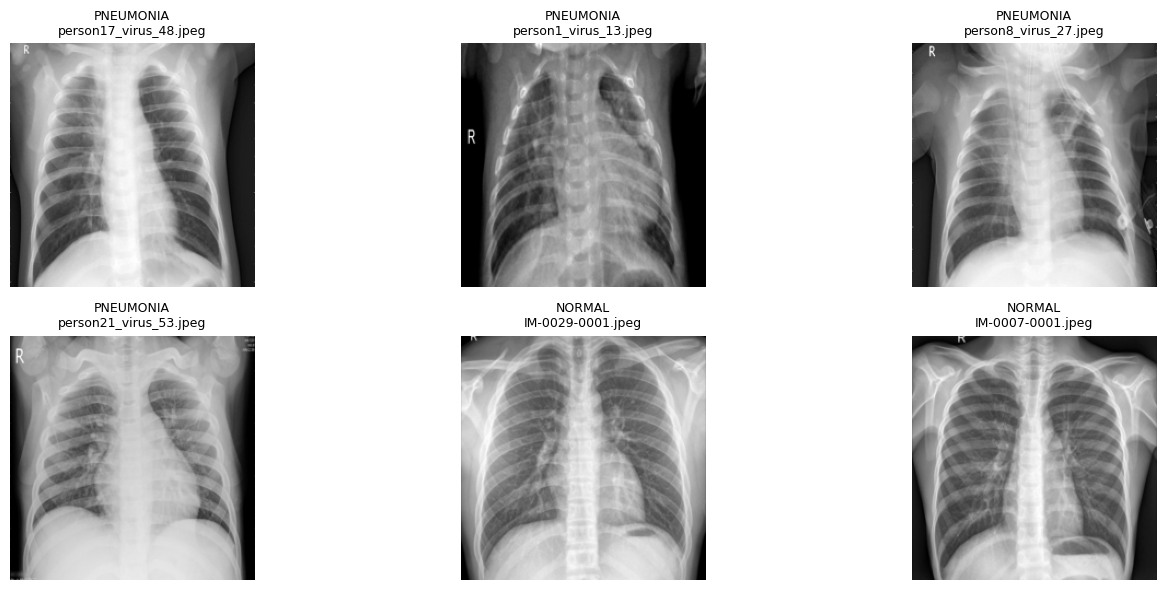

In [ ]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim

# paths
normal_dir = Path("/content/drive/MyDrive/pneumonia images/normal")
pneumonia_dir = Path("/content/drive/MyDrive/pneumonia images/pneumonia")

# load as grayscale arrays
def load_images_from_folder(folder_path, label, target_size=(224, 224)):
    image_list = []

    valid_exts = {".jpg", ".jpeg", ".JPG", ".JPEG"}

    file_paths = sorted([
        p for p in folder_path.iterdir()
        if p.is_file() and p.suffix in valid_exts
    ])

    for fp in file_paths:
        img = Image.open(fp).convert("L")   # grayscale
        img = img.resize(target_size, Image.Resampling.BILINEAR)
        arr = np.array(img).astype(np.float32)

        image_list.append({
            "filename": fp.name,
            "label": label,
            "image": arr
        })

    return image_list

# load both classes
normal_images = load_images_from_folder(normal_dir, label="NORMAL", target_size=(224, 224))
pneumonia_images = load_images_from_folder(pneumonia_dir, label="PNEUMONIA", target_size=(224, 224))

all_images = normal_images + pneumonia_images

print(f"Loaded {len(normal_images)} NORMAL images")
print(f"Loaded {len(pneumonia_images)} PNEUMONIA images")
print(f"Total images: {len(all_images)}")

# sanity check
def show_random_images(image_records, n=6, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(image_records), size=min(n, len(image_records)), replace=False)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs, 1):
        rec = image_records[idx]
        plt.subplot(2, 3, i)
        plt.imshow(rec["image"], cmap="gray")
        plt.title(f'{rec["label"]}\n{rec["filename"]}', fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_images(all_images, n=6)

In [ ]:
# distortion functions

import cv2

# poisson noise for dose simulation
def add_poisson_noise_ct(image, dose_scale, normalize=True):
    image = image.astype(np.float32)

    if normalize:
        img_min, img_max = image.min(), image.max()
        image_norm = (image - img_min) / (img_max - img_min + 1e-8)
    else:
        image_norm = image.copy()

    scaled = image_norm * dose_scale
    scaled = np.clip(scaled, 1e-8, None)

    noisy = np.random.poisson(scaled * 1e4) / 1e4

    if normalize:
        noisy = noisy * (img_max - img_min) + img_min

    return noisy.astype(np.float32)

# gaussian blur
def apply_gaussian_blur(image, sigma):
    blurred = cv2.GaussianBlur(image.astype(np.float32), (0, 0), sigmaX=sigma, sigmaY=sigma)
    return blurred.astype(np.float32)

# resolution degradation
def apply_resolution_degradation(image, scale_factor):
    h, w = image.shape
    new_w = max(1, int(round(w * scale_factor)))
    new_h = max(1, int(round(h * scale_factor)))

    pil_img = Image.fromarray(image.astype(np.uint8))
    down = pil_img.resize((new_w, new_h), Image.Resampling.BILINEAR)
    up = down.resize((w, h), Image.Resampling.BILINEAR)

    return np.array(up).astype(np.float32)

In [ ]:
# SSIM function

def compute_ssim(clean_image, distorted_image):
    clean_image = clean_image.astype(np.float32)
    distorted_image = distorted_image.astype(np.float32)

    data_range = clean_image.max() - clean_image.min()
    if data_range < 1e-8:
        data_range = 1.0

    return ssim(clean_image, distorted_image, data_range=data_range)

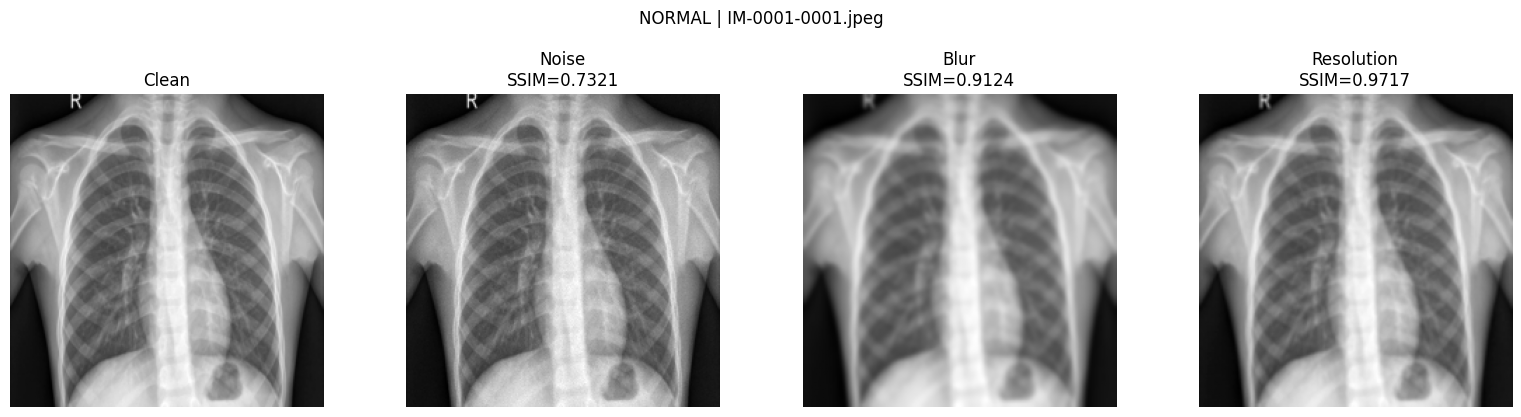

In [ ]:
# Apple distortion and inspect

def preview_distortions(image_record, dose_scale=0.5, blur_sigma=1.5, resolution_scale=0.7):
    clean = image_record["image"]

    noisy = add_poisson_noise_ct(clean, dose_scale=dose_scale)
    blurred = apply_gaussian_blur(clean, sigma=blur_sigma)
    resolution_degraded = apply_resolution_degradation(clean, scale_factor=resolution_scale)

    ssim_noise = compute_ssim(clean, noisy)
    ssim_blur = compute_ssim(clean, blurred)
    ssim_res = compute_ssim(clean, resolution_degraded)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(clean, cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy, cmap="gray")
    plt.title(f"Noise\nSSIM={ssim_noise:.4f}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(blurred, cmap="gray")
    plt.title(f"Blur\nSSIM={ssim_blur:.4f}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(resolution_degraded, cmap="gray")
    plt.title(f"Resolution\nSSIM={ssim_res:.4f}")
    plt.axis("off")

    plt.suptitle(f'{image_record["label"]} | {image_record["filename"]}', y=1.03)
    plt.tight_layout()
    plt.show()

preview_distortions(all_images[0], dose_scale=0.5, blur_sigma=1.5, resolution_scale=0.7)

In [ ]:
# apply distortion across all

import pandas as pd

def evaluate_distortion_set(image_records, distortion_type, param_value, random_seed=42):
    rng = np.random.default_rng(random_seed)
    results = []

    for rec in image_records:
        clean = rec["image"]

        if distortion_type == "noise":
            # reseed each image so results are reproducible
            np.random.seed(rng.integers(0, 1_000_000))
            distorted = add_poisson_noise_ct(clean, dose_scale=param_value)

        elif distortion_type == "blur":
            distorted = apply_gaussian_blur(clean, sigma=param_value)

        elif distortion_type == "resolution":
            distorted = apply_resolution_degradation(clean, scale_factor=param_value)

        else:
            raise ValueError("distortion_type must be 'noise', 'blur', or 'resolution'")

        score = compute_ssim(clean, distorted)

        results.append({
            "filename": rec["filename"],
            "label": rec["label"],
            "distortion_type": distortion_type,
            "param_value": param_value,
            "ssim": score
        })

    return pd.DataFrame(results)

In [ ]:
# tune degradation so values fall within SSIM values


mild_target = 0.90
tolerance = 0.005
max_iters = 100

# initial guess
noise_param = 0.50        # lower -> more noise -> lower SSIM
blur_param = 1.50         # higher -> more blur -> lower SSIM
res_param = 0.70          # lower -> more degradation -> lower SSIM

# step sizes
blur_step = 0.10
res_step = 0.03

# bounds
noise_min, noise_max = 0.01, 2.0
blur_min, blur_max = 0.01, 10.0
res_min, res_max = 0.05, 1.0

# compute mean SSIM
def get_mean_ssim(image_records, distortion_type, param_value):
    df = evaluate_distortion_set(
        image_records,
        distortion_type=distortion_type,
        param_value=param_value
    )
    return df, df["ssim"].mean()

# tuning loop
history = []

for i in range(max_iters):
    df_noise, noise_mean = get_mean_ssim(all_images, "noise", noise_param)
    df_blur,  blur_mean  = get_mean_ssim(all_images, "blur", blur_param)
    df_res,   res_mean   = get_mean_ssim(all_images, "resolution", res_param)

    history.append({
        "iter": i + 1,
        "noise_param": noise_param,
        "noise_mean": noise_mean,
        "blur_param": blur_param,
        "blur_mean": blur_mean,
        "res_param": res_param,
        "res_mean": res_mean
    })

    print(f"Iteration {i+1}")
    print(f"  Noise      | param={noise_param:.4f} | mean SSIM={noise_mean:.4f}")
    print(f"  Blur       | param={blur_param:.4f}  | mean SSIM={blur_mean:.4f}")
    print(f"  Resolution | param={res_param:.4f}  | mean SSIM={res_mean:.4f}")
    print("-" * 60)

    # Check if all 3 are within target band
    noise_ok = abs(noise_mean - mild_target) <= tolerance
    blur_ok  = abs(blur_mean  - mild_target) <= tolerance
    res_ok   = abs(res_mean   - mild_target) <= tolerance

    if noise_ok and blur_ok and res_ok:
        print("All three distortion types are within target tolerance.")
        break


    if not noise_ok:
        if noise_mean > mild_target:
            # too little distortion, need lower SSIM
            noise_param -= noise_step
        else:
            # too much distortion, need higher SSIM
            noise_param += noise_step

        noise_param = min(max(noise_param, noise_min), noise_max)

    if not blur_ok:
        if blur_mean > mild_target:
            # too little distortion, need lower SSIM
            blur_param += blur_step
        else:
            # too much distortion, need higher SSIM
            blur_param -= blur_step

        blur_param = min(max(blur_param, blur_min), blur_max)

    if not res_ok:
        if res_mean > mild_target:
            # too little distortion, need lower SSIM
            res_param -= res_step
        else:
            # too much distortion, need higher SSIM
            res_param += res_step

        res_param = min(max(res_param, res_min), res_max)

    noise_step = max(noise_step * 0.95, 0.001)
    blur_step  = max(blur_step  * 0.95, 0.005)
    res_step   = max(res_step   * 0.95, 0.001)

else:
    print("Reached max_iters before all three were within tolerance.")

#results
print("\nFinal tuned parameters:")
print(f"Noise param      = {noise_param:.4f}, mean SSIM = {noise_mean:.4f}")
print(f"Blur param       = {blur_param:.4f}, mean SSIM = {blur_mean:.4f}")
print(f"Resolution param = {res_param:.4f}, mean SSIM = {res_mean:.4f}")

# Final dataframes
final_df_noise = df_noise
final_df_blur = df_blur
final_df_res = df_res

Iteration 1
  Noise      | param=0.5000 | mean SSIM=0.7133
  Blur       | param=1.5000  | mean SSIM=0.9180
  Resolution | param=0.7000  | mean SSIM=0.9720
------------------------------------------------------------
Iteration 2
  Noise      | param=0.5500 | mean SSIM=0.7689
  Blur       | param=1.6000  | mean SSIM=0.9091
  Resolution | param=0.6700  | mean SSIM=0.9690
------------------------------------------------------------
Iteration 3
  Noise      | param=0.5975 | mean SSIM=0.8155
  Blur       | param=1.6950  | mean SSIM=0.9006
  Resolution | param=0.6415  | mean SSIM=0.9658
------------------------------------------------------------
Iteration 4
  Noise      | param=0.6426 | mean SSIM=0.8541
  Blur       | param=1.6950  | mean SSIM=0.9006
  Resolution | param=0.6144  | mean SSIM=0.9628
------------------------------------------------------------
Iteration 5
  Noise      | param=0.6855 | mean SSIM=0.8856
  Blur       | param=1.6950  | mean SSIM=0.9006
  Resolution | param=0.5887  

In [ ]:
#same as before for medium

medium_target = 0.70
tolerance = 0.005

noise_param = 0.50
blur_param = 3.6
res_param = 0.70

noise_step = 0.05
blur_step = 0.10
res_step = 0.03

noise_min, noise_max = 0.01, 2.0
blur_min, blur_max = 0.01, 10.0
res_min, res_max = 0.05, 1.0

def get_mean_ssim(image_records, distortion_type, param_value):
    df = evaluate_distortion_set(
        image_records,
        distortion_type=distortion_type,
        param_value=param_value
    )
    return df, df["ssim"].mean()

history = []

for i in range(max_iters):
    df_noise, noise_mean = get_mean_ssim(all_images, "noise", noise_param)
    df_blur,  blur_mean  = get_mean_ssim(all_images, "blur", blur_param)
    df_res,   res_mean   = get_mean_ssim(all_images, "resolution", res_param)

    history.append({
        "iter": i + 1,
        "noise_param": noise_param,
        "noise_mean": noise_mean,
        "blur_param": blur_param,
        "blur_mean": blur_mean,
        "res_param": res_param,
        "res_mean": res_mean
    })

    print(f"Iteration {i+1}")
    print(f"  Noise      | param={noise_param:.4f} | mean SSIM={noise_mean:.4f}")
    print(f"  Blur       | param={blur_param:.4f}  | mean SSIM={blur_mean:.4f}")
    print(f"  Resolution | param={res_param:.4f}  | mean SSIM={res_mean:.4f}")
    print("-" * 60)

    # Check if all 3 are within target band
    noise_ok = abs(noise_mean - medium_target) <= tolerance
    blur_ok  = abs(blur_mean  - medium_target) <= tolerance
    res_ok   = abs(res_mean   - medium_target) <= tolerance

    if noise_ok and blur_ok and res_ok:
        print("All three distortion types are within target tolerance.")
        break

    if not noise_ok:
        if noise_mean > medium_target:
            # too little distortion, need lower SSIM
            noise_param -= noise_step
        else:
            # too much distortion, need higher SSIM
            noise_param += noise_step

        noise_param = min(max(noise_param, noise_min), noise_max)


    if not blur_ok:
        if blur_mean > medium_target:
            # too little distortion, need lower SSIM
            blur_param += blur_step
        else:
            # too much distortion, need higher SSIM
            blur_param -= blur_step

        blur_param = min(max(blur_param, blur_min), blur_max)


    if not res_ok:
        if res_mean > medium_target:
            # too little distortion, need lower SSIM
            res_param -= res_step
        else:
            # too much distortion, need higher SSIM
            res_param += res_step

        res_param = min(max(res_param, res_min), res_max)

    noise_step = max(noise_step * 0.95, 0.001)
    blur_step  = max(blur_step  * 0.95, 0.005)
    res_step   = max(res_step   * 0.95, 0.001)

else:
    print("Reached max_iters before all three were within tolerance.")


print("\nFinal tuned parameters:")
print(f"Noise param      = {noise_param:.4f}, mean SSIM = {noise_mean:.4f}")
print(f"Blur param       = {blur_param:.4f}, mean SSIM = {blur_mean:.4f}")
print(f"Resolution param = {res_param:.4f}, mean SSIM = {res_mean:.4f}")

final_df_noise = df_noise
final_df_blur = df_blur
final_df_res = df_res

Iteration 1
  Noise      | param=0.5000 | mean SSIM=0.7133
  Blur       | param=3.6000  | mean SSIM=0.7497
  Resolution | param=0.7000  | mean SSIM=0.9720
------------------------------------------------------------
Iteration 2
  Noise      | param=0.4500 | mean SSIM=0.6515
  Blur       | param=3.7000  | mean SSIM=0.7433
  Resolution | param=0.6700  | mean SSIM=0.9690
------------------------------------------------------------
Iteration 3
  Noise      | param=0.4975 | mean SSIM=0.7103
  Blur       | param=3.7950  | mean SSIM=0.7373
  Resolution | param=0.6415  | mean SSIM=0.9658
------------------------------------------------------------
Iteration 4
  Noise      | param=0.4524 | mean SSIM=0.6546
  Blur       | param=3.8853  | mean SSIM=0.7318
  Resolution | param=0.6144  | mean SSIM=0.9628
------------------------------------------------------------
Iteration 5
  Noise      | param=0.4952 | mean SSIM=0.7076
  Blur       | param=3.9710  | mean SSIM=0.7266
  Resolution | param=0.5887  

In [ ]:
# ============================================
# 1) Build dataframe of matched distortion parameters
# ============================================

import pandas as pd

distortion_levels_df = pd.DataFrame({
    "severity": ["Mild", "Medium", "Heavy"],
    "target_ssim": [0.9, 0.8, 0.7],
    "noise_param": [0.7151, 0.5856, 0.4914],
    "blur_param": [1.6950, 2.8529, 4.4025],
    "resolution_param": [0.3641, 0.2162, 0.1396]
})

display(distortion_levels_df)

,severity,target_ssim,noise_param,blur_param,resolution_param
0,Mild,0.9,0.7151,1.6950,0.3641
1,Medium,0.8,0.5856,2.8529,0.2162
2,Heavy,0.7,0.4914,4.4025,0.1396


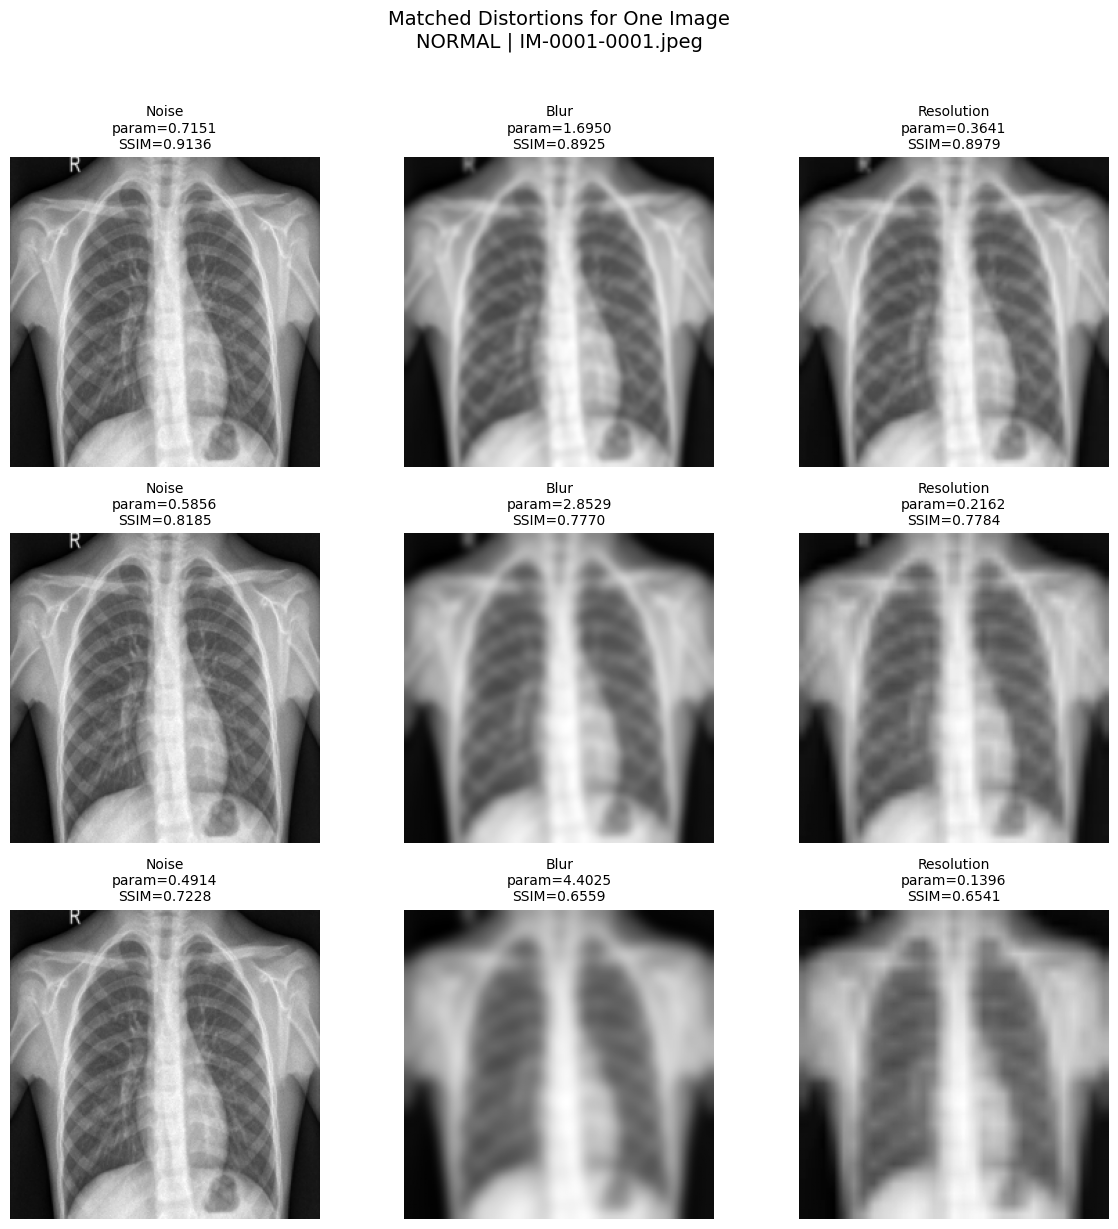

In [ ]:
# ============================================
# 2) Plot 3x3 grid:
#    rows = Mild / Medium / Heavy
#    cols = Noise / Blur / Resolution
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Choose one image to visualize
# Change this index if you want a different image
image_idx = 0
clean_image = all_images[image_idx]["image"]
image_label = all_images[image_idx]["label"]
image_name = all_images[image_idx]["filename"]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row_idx, row in distortion_levels_df.iterrows():
    severity = row["severity"]
    target_ssim = row["target_ssim"]

    # Apply each distortion at this severity
    noisy_img = add_poisson_noise_ct(clean_image, dose_scale=row["noise_param"])
    blurred_img = apply_gaussian_blur(clean_image, sigma=row["blur_param"])
    res_img = apply_resolution_degradation(clean_image, scale_factor=row["resolution_param"])

    # Compute actual SSIMs for display
    noisy_ssim = compute_ssim(clean_image, noisy_img)
    blur_ssim = compute_ssim(clean_image, blurred_img)
    res_ssim = compute_ssim(clean_image, res_img)

    images = [noisy_img, blurred_img, res_img]
    titles = [
        f"Noise\nparam={row['noise_param']:.4f}\nSSIM={noisy_ssim:.4f}",
        f"Blur\nparam={row['blur_param']:.4f}\nSSIM={blur_ssim:.4f}",
        f"Resolution\nparam={row['resolution_param']:.4f}\nSSIM={res_ssim:.4f}"
    ]

    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx], cmap="gray")
        ax.set_title(titles[col_idx], fontsize=10)
        ax.axis("off")

        # Row labels on leftmost column
        if col_idx == 0:
            ax.set_ylabel(f"{severity}\n(target={target_ssim})", fontsize=11)

plt.suptitle(f"Matched Distortions for One Image\n{image_label} | {image_name}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()